# pMHC-TCR dataset — ProteinMPNN native recovery

The IF protocol (ProteinMPNN, **no Met@P1 + no Pro**, T=0.1, 2000 designs/structure) run across
**22 TCR-pMHC class I complexes** (NY-ESO-1, Flu, MART-1, CMV, Tax, gp100, HIV…). This notebook
quantifies how well the designs recover each native epitope, and whether recovery generalises.

Sections: ranking · Pro vs non-Pro · per-position recovery · anchors · best designs ·
NY-ESO-1 cross-crystal consistency · single-vs-relaxed ensemble (when ready).

In [1]:
from pathlib import Path
import csv, glob, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
try: from IPython.display import display
except Exception: display=print
warnings.filterwarnings("ignore"); sns.set_style("whitegrid"); plt.rcParams["figure.dpi"]=110
ROOT=Path("/home/ubuntu/if-mhc"); DP=ROOT/"outputs/dataset_protocol"
FIG=ROOT/"outputs/dataset_protocol/figures"; FIG.mkdir(parents=True,exist_ok=True)
AA=list("ACDEFGHIKLMNPQRSTVWY"); AA_IDX={a:i for i,a in enumerate(AA)}

ds={r["pdb"]:r for r in csv.DictReader(open(ROOT/"inputs/pmhc_tcr_dataset/dataset.csv")) if r["valid"]=="True"}
native={p:ds[p]["peptide"] for p in ds}

def designs(pdb):
    fa=DP/"seqs"/f"{pdb}.fa"; out=[]
    if not fa.exists(): return out
    ls=fa.read_text().splitlines()
    for i in range(0,len(ls)-1,2):
        h,s=ls[i],ls[i+1].strip()
        if "sample=" in h: out.append(s)
    return out

rec=pd.read_csv(DP/"recovery.csv") if (DP/"recovery.csv").exists() else None
print("structures:",len(ds),"| recovery.csv:", "loaded" if rec is not None else "pending")
display(rec)

structures: 22 | recovery.csv: loaded


,pdb,native,len,n,mean_id,max_id,exact,best_design,has_Pro_native
0,1OGA,GILGFVFTL,9,2000,65.1,77.8,0,SVLGFVFTL,False
1,2F53,SLLMWITQC,9,2000,57.9,77.8,0,SLLEWITQL,False
2,2BNR,SLLMWITQC,9,2000,56.9,77.8,0,SLLDWITQL,False
3,3QDG,ELAGIGILTV,10,2000,53.8,80.0,0,ALAGIGILTW,False
4,2VLR,GILGFVFTL,9,2000,51.4,88.9,0,GILGFTFTL,False
5,5NME,SLYNTVATL,9,2000,47.9,66.7,0,SLYSGIATL,False
6,2P5E,SLLMWITQC,9,2000,46.3,66.7,0,SLLNWDTQF,False
7,5HHO,GILEFVFTL,9,2000,45.7,66.7,0,GTLTFVSTL,False
8,3HG1,ELAGIGILTV,10,2000,44.7,70.0,0,ALAGIGIVTL,False
9,3QFJ,LLFGFPVYV,9,2000,41.8,55.6,0,LLFGFARVA,True


## 1. Native-recovery ranking (red = native contains Proline → capped by no-Pro)

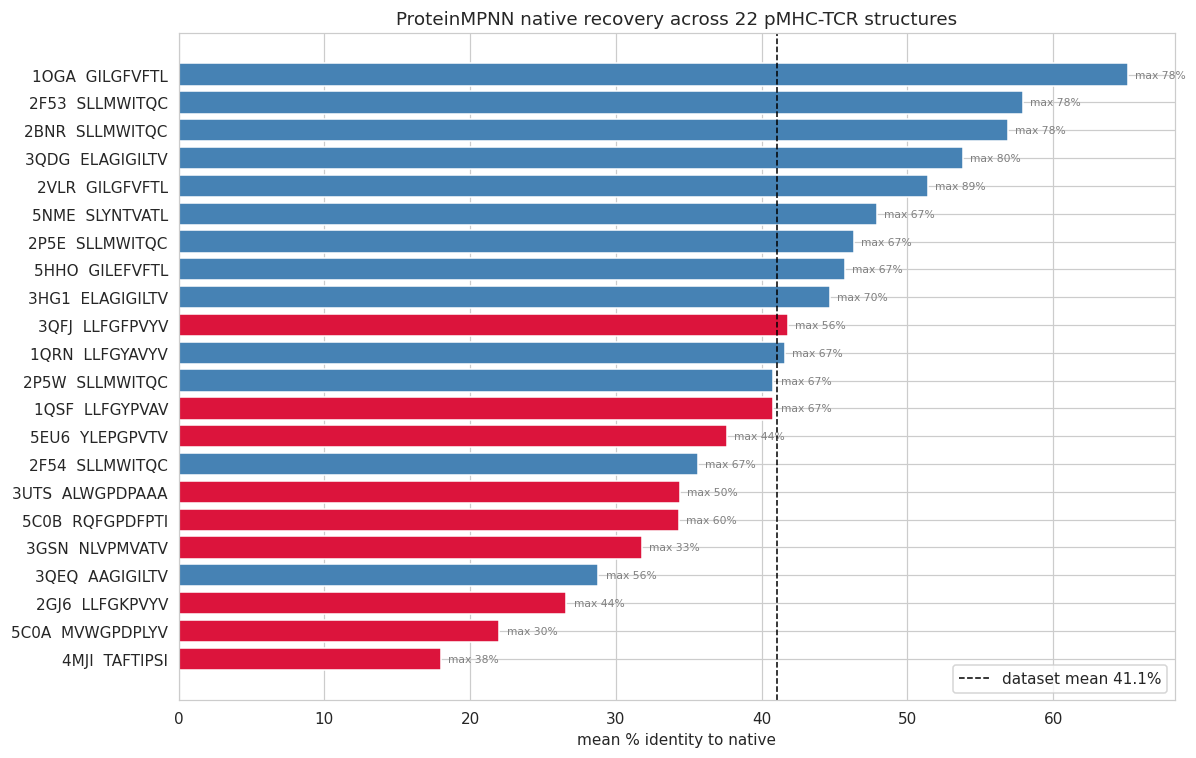

In [2]:
r=rec.sort_values("mean_id")
fig,ax=plt.subplots(figsize=(11,7))
colors=["crimson" if hp else "steelblue" for hp in r["has_Pro_native"]]
ax.barh(r["pdb"]+"  "+r["native"], r["mean_id"], color=colors)
ax.errorbar(r["mean_id"], range(len(r)), xerr=None, fmt="none")
for i,(_,row) in enumerate(r.iterrows()):
    ax.text(row["mean_id"]+0.5,i,f"max {row['max_id']:.0f}%",va="center",fontsize=7,color="grey")
ax.axvline(r["mean_id"].mean(),ls="--",c="k",lw=1,label=f"dataset mean {r['mean_id'].mean():.1f}%")
ax.set_xlabel("mean % identity to native"); ax.legend()
ax.set_title("ProteinMPNN native recovery across 22 pMHC-TCR structures")
plt.tight_layout(); plt.savefig(FIG/"recovery_ranking.png",bbox_inches="tight"); plt.show()

## 2. The key finding: Pro-containing natives are capped by the no-Pro constraint

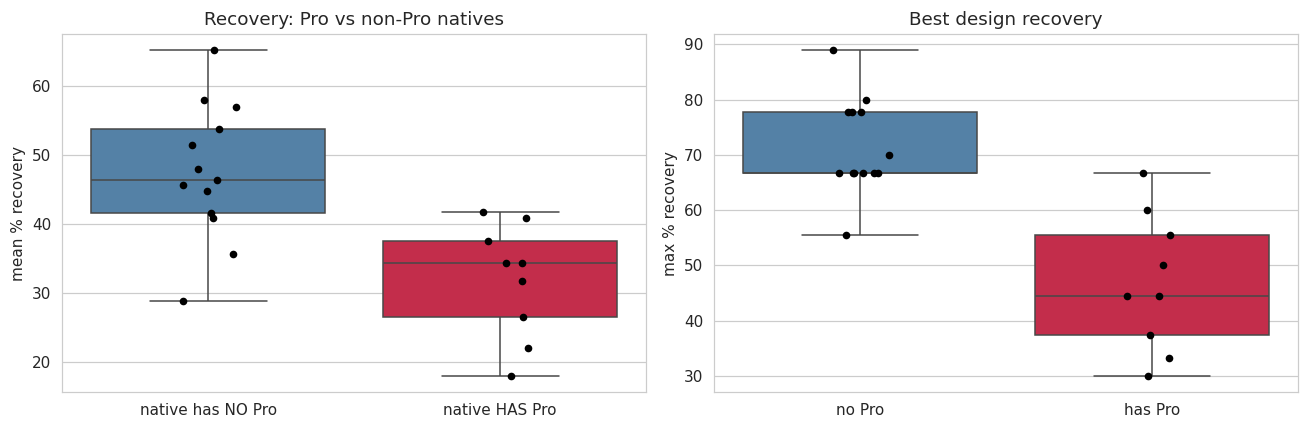

mean recovery — non-Pro natives: 47.4%  |  Pro natives: 31.9%


In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
sns.boxplot(data=rec,x="has_Pro_native",y="mean_id",ax=ax[0],palette=["steelblue","crimson"])
sns.stripplot(data=rec,x="has_Pro_native",y="mean_id",ax=ax[0],color="k",size=5)
ax[0].set_xticklabels(["native has NO Pro","native HAS Pro"]); ax[0].set_ylabel("mean % recovery"); ax[0].set_xlabel("")
ax[0].set_title("Recovery: Pro vs non-Pro natives")
sns.boxplot(data=rec,x="has_Pro_native",y="max_id",ax=ax[1],palette=["steelblue","crimson"])
sns.stripplot(data=rec,x="has_Pro_native",y="max_id",ax=ax[1],color="k",size=5)
ax[1].set_xticklabels(["no Pro","has Pro"]); ax[1].set_ylabel("max % recovery"); ax[1].set_xlabel(""); ax[1].set_title("Best design recovery")
plt.tight_layout(); plt.savefig(FIG/"pro_vs_nonpro.png",bbox_inches="tight"); plt.show()
g=rec.groupby("has_Pro_native")["mean_id"].mean()
print(f"mean recovery — non-Pro natives: {g.get(False,float('nan')):.1f}%  |  Pro natives: {g.get(True,float('nan')):.1f}%")

## 3. Per-position recovery heatmap (each structure's epitope)

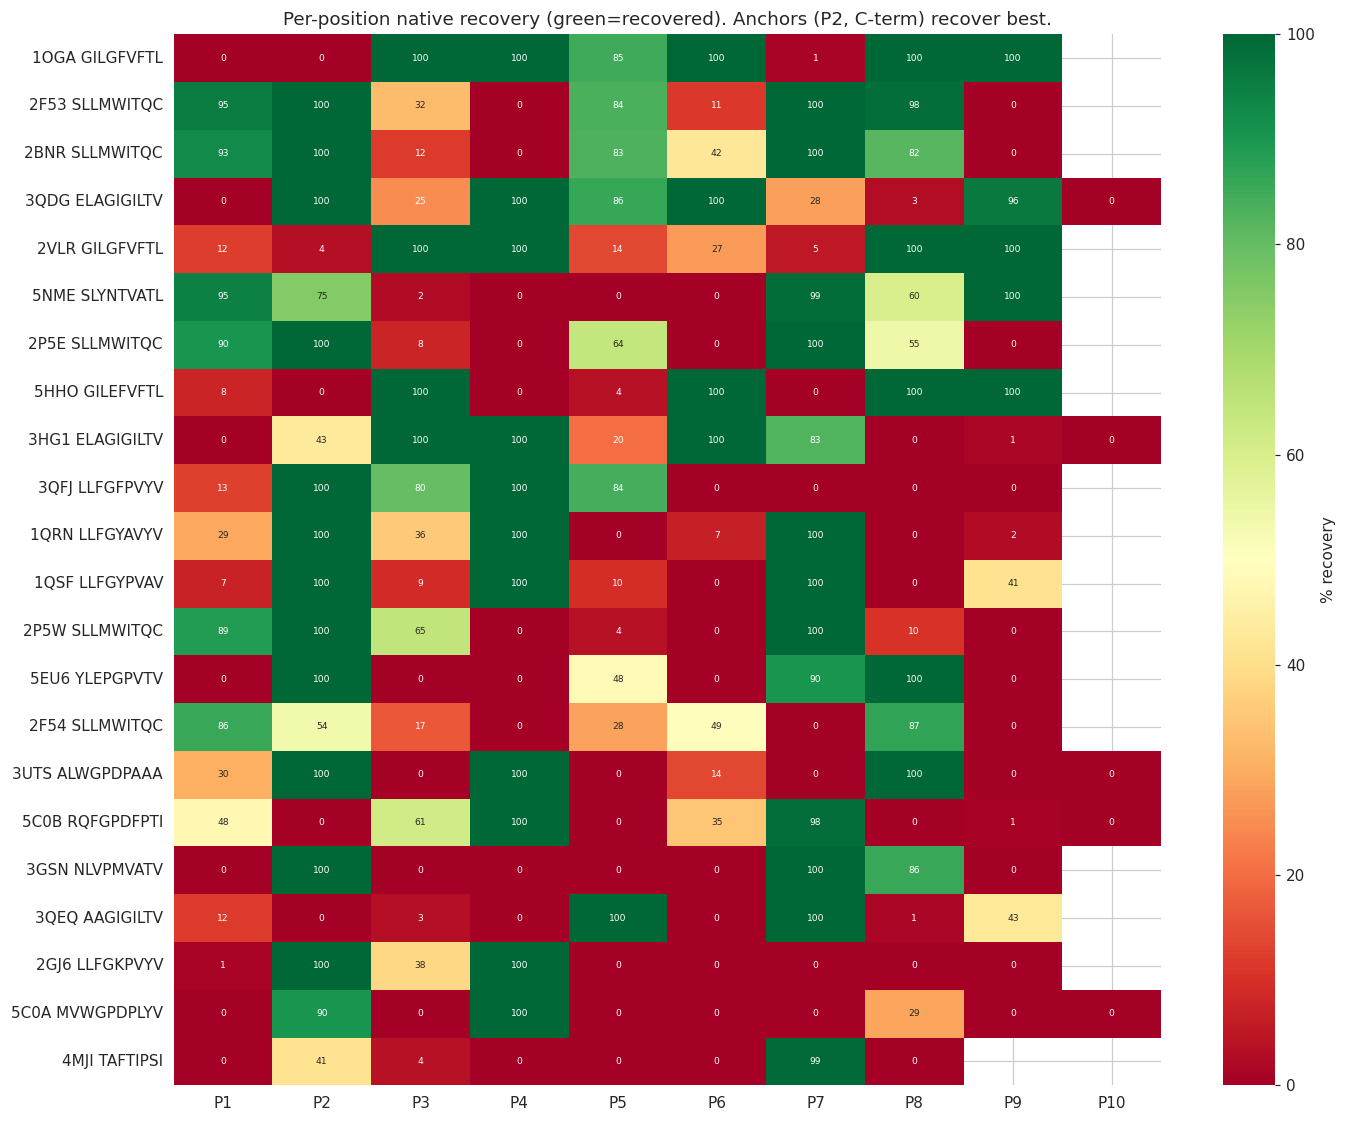

In [4]:
maxL=int(rec["len"].max()); rows=[]; idx=[]
for pdb in rec.sort_values("mean_id",ascending=False)["pdb"]:
    nat=native[pdb]; seqs=[s for s in designs(pdb) if len(s)==len(nat)]
    if not seqs: continue
    P=np.array([list(s) for s in seqs]); na=np.array(list(nat))
    rec_pos=(P==na).mean(0)*100
    row=list(rec_pos)+[np.nan]*(maxL-len(nat)); rows.append(row); idx.append(f"{pdb} {nat}")
H=pd.DataFrame(rows,index=idx,columns=[f"P{i+1}" for i in range(maxL)])
fig,ax=plt.subplots(figsize=(1.0*maxL+3,0.4*len(H)+1.5))
sns.heatmap(H,cmap="RdYlGn",vmin=0,vmax=100,annot=True,fmt=".0f",annot_kws={"size":6},
            cbar_kws={"label":"% recovery"},ax=ax)
ax.set_title("Per-position native recovery (green=recovered). Anchors (P2, C-term) recover best.")
plt.tight_layout(); plt.savefig(FIG/"perposition_heatmap.png",bbox_inches="tight"); plt.show()

## 4. Anchor recovery — P2 and C-terminal (PΩ) across the panel

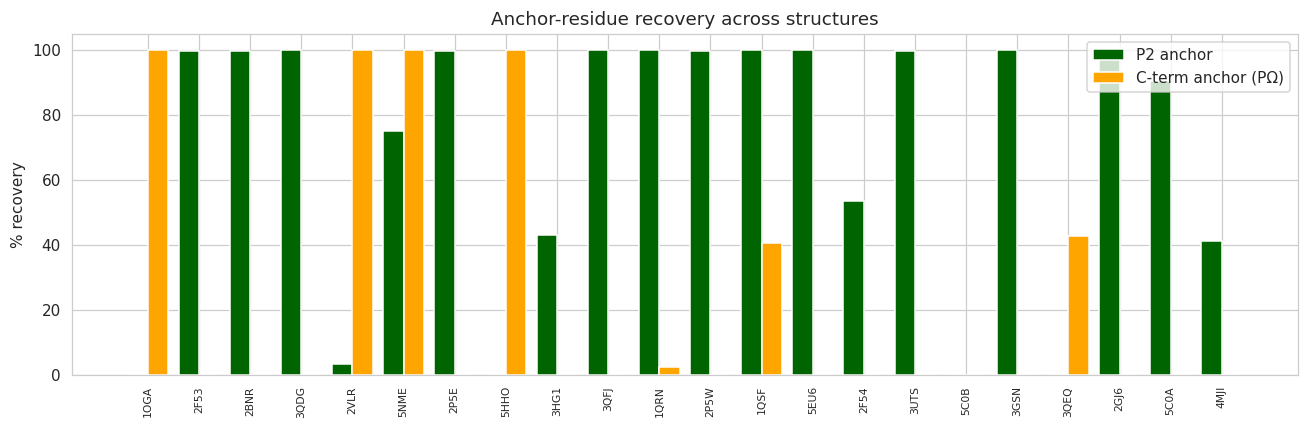

mean P2 recovery: 68%  |  mean PΩ recovery: 22%


In [5]:
rows=[]
for pdb in rec["pdb"]:
    nat=native[pdb]; seqs=[s for s in designs(pdb) if len(s)==len(nat)]
    if not seqs: continue
    P=np.array([list(s) for s in seqs]); na=np.array(list(nat))
    rows.append({"pdb":pdb,"P2":(P[:,1]==na[1]).mean()*100,"POmega":(P[:,-1]==na[-1]).mean()*100,
                 "mean":(P==na).mean()*100})
ad=pd.DataFrame(rows).sort_values("mean",ascending=False)
x=np.arange(len(ad)); w=0.4
fig,ax=plt.subplots(figsize=(12,4))
ax.bar(x-w/2,ad["P2"],w,label="P2 anchor",color="darkgreen")
ax.bar(x+w/2,ad["POmega"],w,label="C-term anchor (PΩ)",color="orange")
ax.set_xticks(x); ax.set_xticklabels(ad["pdb"],rotation=90,fontsize=7)
ax.set_ylabel("% recovery"); ax.legend(); ax.set_title("Anchor-residue recovery across structures")
plt.tight_layout(); plt.savefig(FIG/"anchor_recovery.png",bbox_inches="tight"); plt.show()
print(f"mean P2 recovery: {ad['P2'].mean():.0f}%  |  mean PΩ recovery: {ad['POmega'].mean():.0f}%")

## 5. Best design vs native (closest design per structure)

In [6]:
rows=[]
for _,row in rec.sort_values("mean_id",ascending=False).iterrows():
    nat=row["native"]; bd=row["best_design"]
    match="".join("|" if a==b else "." for a,b in zip(nat,bd))
    rows.append({"pdb":row["pdb"],"native":nat,"match":match,"best_design":bd,
                 "max_id%":row["max_id"]})
display(pd.DataFrame(rows))

,pdb,native,match,best_design,max_id%
0,1OGA,GILGFVFTL,..|||||||,SVLGFVFTL,77.8
1,2F53,SLLMWITQC,|||.||||.,SLLEWITQL,77.8
2,2BNR,SLLMWITQC,|||.||||.,SLLDWITQL,77.8
3,3QDG,ELAGIGILTV,.||||||||.,ALAGIGILTW,80.0
4,2VLR,GILGFVFTL,|||||.|||,GILGFTFTL,88.9
5,5NME,SLYNTVATL,|||...|||,SLYSGIATL,66.7
6,2P5E,SLLMWITQC,|||.|.||.,SLLNWDTQF,66.7
7,5HHO,GILEFVFTL,|.|.||.||,GTLTFVSTL,66.7
8,3HG1,ELAGIGILTV,.||||||.|.,ALAGIGIVTL,70.0
9,3QFJ,LLFGFPVYV,|||||....,LLFGFARVA,55.6


## 6. NY-ESO-1 (SLLMWITQC) consistency across 5 crystal forms

NY-ESO-1 structures: ['2P5E', '2P5W', '2BNR', '2F53', '2F54'] | pooled designs: 10000


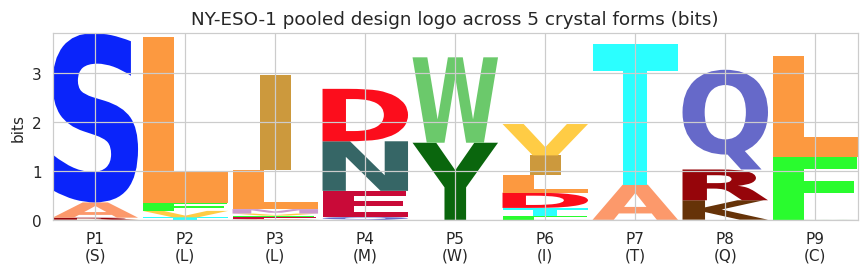

In [7]:
import logomaker
nyeso=[p for p in ds if native[p]=="SLLMWITQC"]
allseq=[s for p in nyeso for s in designs(p) if len(s)==9]
print("NY-ESO-1 structures:",nyeso,"| pooled designs:",len(allseq))
if allseq:
    M=np.zeros((9,20))
    for s in allseq:
        for i,c in enumerate(s):
            if c in AA_IDX: M[i,AA_IDX[c]]+=1
    f=pd.DataFrame(M/M.sum(1,keepdims=True),columns=AA,index=list(range(9)))
    info=logomaker.transform_matrix(f.copy(),from_type="probability",to_type="information")
    fig,ax=plt.subplots(figsize=(8,2.6)); logomaker.Logo(info,ax=ax,color_scheme="skylign_protein")
    ax.set_xticks(range(9)); ax.set_xticklabels([f"P{i+1}\n({'SLLMWITQC'[i]})" for i in range(9)])
    ax.set_title(f"NY-ESO-1 pooled design logo across {len(nyeso)} crystal forms (bits)"); ax.set_ylabel("bits")
    plt.tight_layout(); plt.savefig(FIG/"nyeso_logo.png",bbox_inches="tight"); plt.show()

## 7. Single-structure vs relaxed-ensemble recovery (fills in when P5 finishes)

In [8]:
rrp=ROOT/"outputs/dataset_relax/recovery_relaxed.csv"
if not rrp.exists():
    print("relaxed-ensemble recovery not ready yet — re-run this cell later.")
else:
    rr=pd.read_csv(rrp); m=rr.merge(rec[["pdb","mean_id"]].rename(columns={"mean_id":"single"}),on="pdb")
    fig,ax=plt.subplots(figsize=(6,6))
    ax.scatter(m["single"],m["relaxed_mean_id"],c=["crimson" if h else "steelblue" for h in m["has_Pro_native"]],s=40)
    lim=[0,max(m[["single","relaxed_mean_id"]].max())+5]; ax.plot(lim,lim,"k--",lw=1)
    for _,row in m.iterrows(): ax.annotate(row["pdb"],(row["single"],row["relaxed_mean_id"]),fontsize=6)
    ax.set_xlabel("single-structure recovery %"); ax.set_ylabel("relaxed-ensemble recovery %")
    ax.set_title("Does conformational sampling improve recovery? (above line = yes)")
    plt.tight_layout(); plt.savefig(FIG/"single_vs_relaxed.png",bbox_inches="tight"); plt.show()
    print(f"mean single {m['single'].mean():.1f}% vs relaxed {m['relaxed_mean_id'].mean():.1f}%")

relaxed-ensemble recovery not ready yet — re-run this cell later.
